In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data.csv")
df.head()

,V0,V1,V2,V3,V4,V5,V6,V7,V8
0,ADT1_YEAST,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22
1,ADT2_YEAST,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22
2,ADT3_YEAST,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22
3,AAR2_YEAST,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22
4,AATM_YEAST,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22


In [3]:
print("Shape (rows, cols):", df.shape)
print("\nHead:")
print(df.head())

print("\nDtypes:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

Shape (rows, cols): (1484, 9)

Head:
           V0    V1    V2    V3    V4   V5   V6    V7    V8
0  ADT1_YEAST  0.58  0.61  0.47  0.13  0.5  0.0  0.48  0.22
1  ADT2_YEAST  0.43  0.67  0.48  0.27  0.5  0.0  0.53  0.22
2  ADT3_YEAST  0.64  0.62  0.49  0.15  0.5  0.0  0.53  0.22
3  AAR2_YEAST  0.58  0.44  0.57  0.13  0.5  0.0  0.54  0.22
4  AATM_YEAST  0.42  0.44  0.48  0.54  0.5  0.0  0.48  0.22

Dtypes:
V0     object
V1    float64
V2    float64
V3    float64
V4    float64
V5    float64
V6    float64
V7    float64
V8    float64
dtype: object

Missing values per column:
V0    0
V1    0
V2    0
V3    0
V4    0
V5    0
V6    0
V7    0
V8    0
dtype: int64


In [4]:
# Separate numeric/non-numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = df.columns.difference(numeric_cols).tolist()

In [5]:
print("\nNumeric columns:", numeric_cols)
print("Non-numeric columns:", non_numeric_cols)


Numeric columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8']
Non-numeric columns: ['V0']


In [6]:
print("\nDescriptive statistics (numeric):")
print(df[numeric_cols].describe().T)


Descriptive statistics (numeric):
     count      mean       std   min   25%   50%   75%   max
V1  1484.0  0.500121  0.137299  0.11  0.41  0.49  0.58  1.00
V2  1484.0  0.499933  0.123924  0.13  0.42  0.49  0.57  1.00
V3  1484.0  0.500034  0.086670  0.21  0.46  0.51  0.55  1.00
V4  1484.0  0.261186  0.137098  0.00  0.17  0.22  0.32  1.00
V5  1484.0  0.504717  0.048351  0.50  0.50  0.50  0.50  1.00
V6  1484.0  0.007500  0.075683  0.00  0.00  0.00  0.00  0.83
V7  1484.0  0.499885  0.057797  0.00  0.48  0.51  0.53  0.73
V8  1484.0  0.276199  0.106491  0.00  0.22  0.22  0.30  1.00


In [7]:
# Optional: show distribution skewness/kurtosis quickly
print("\nSkewness (numeric):")
print(df[numeric_cols].skew(numeric_only=True))


Skewness (numeric):
V1     0.604291
V2     0.416639
V3    -0.220995
V4     1.444776
V5    10.159633
V6    10.276884
V7    -1.791641
V8     2.413031
dtype: float64


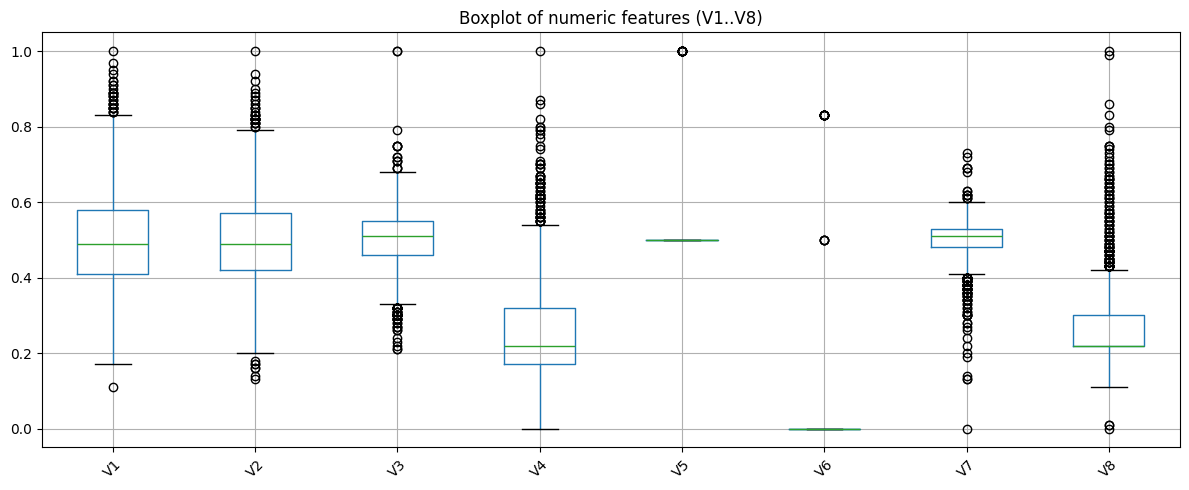

In [8]:
# ---------- Distribution plots: boxplot ----------
plt.figure(figsize=(12, 5))
df[numeric_cols].boxplot()
plt.title("Boxplot of numeric features (V1..V8)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

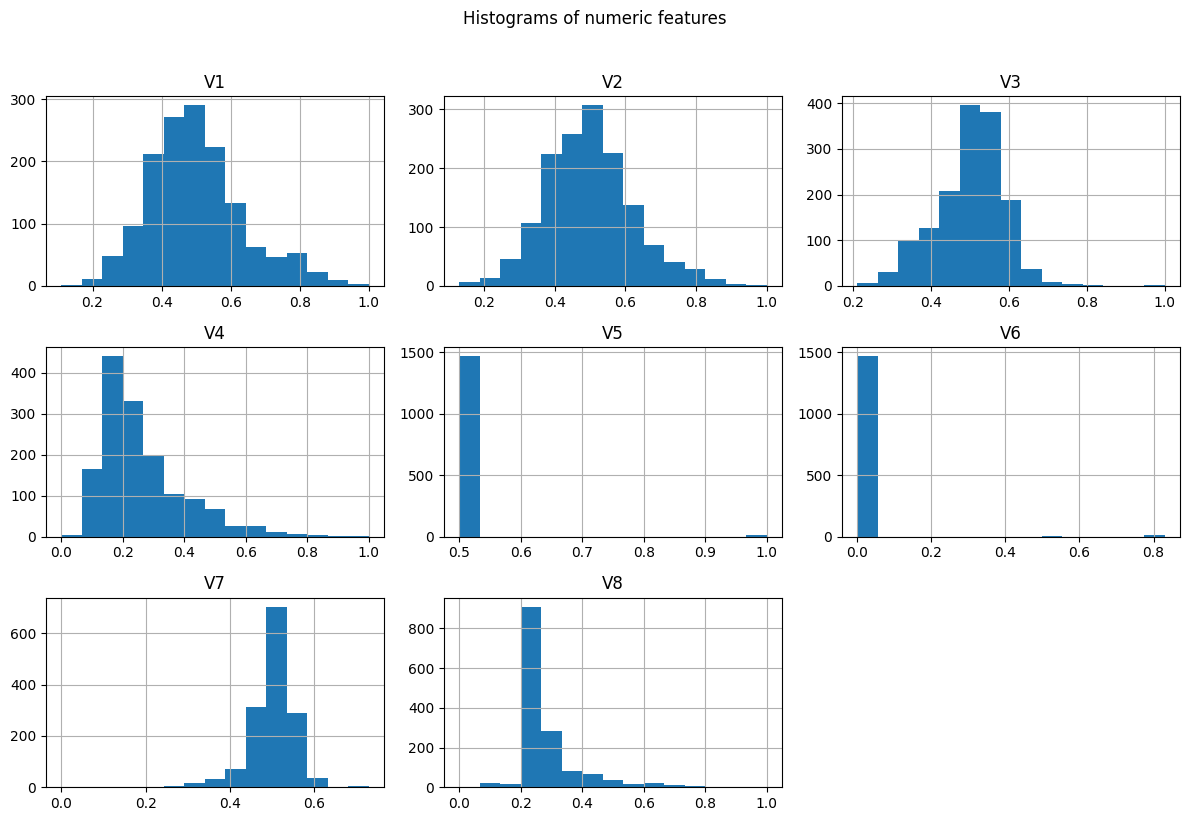

In [9]:
# Optional: histograms (useful when asked for “distributions”)
df[numeric_cols].hist(bins=15, figsize=(12, 8))
plt.suptitle("Histograms of numeric features", y=1.02)
plt.tight_layout()
plt.show()


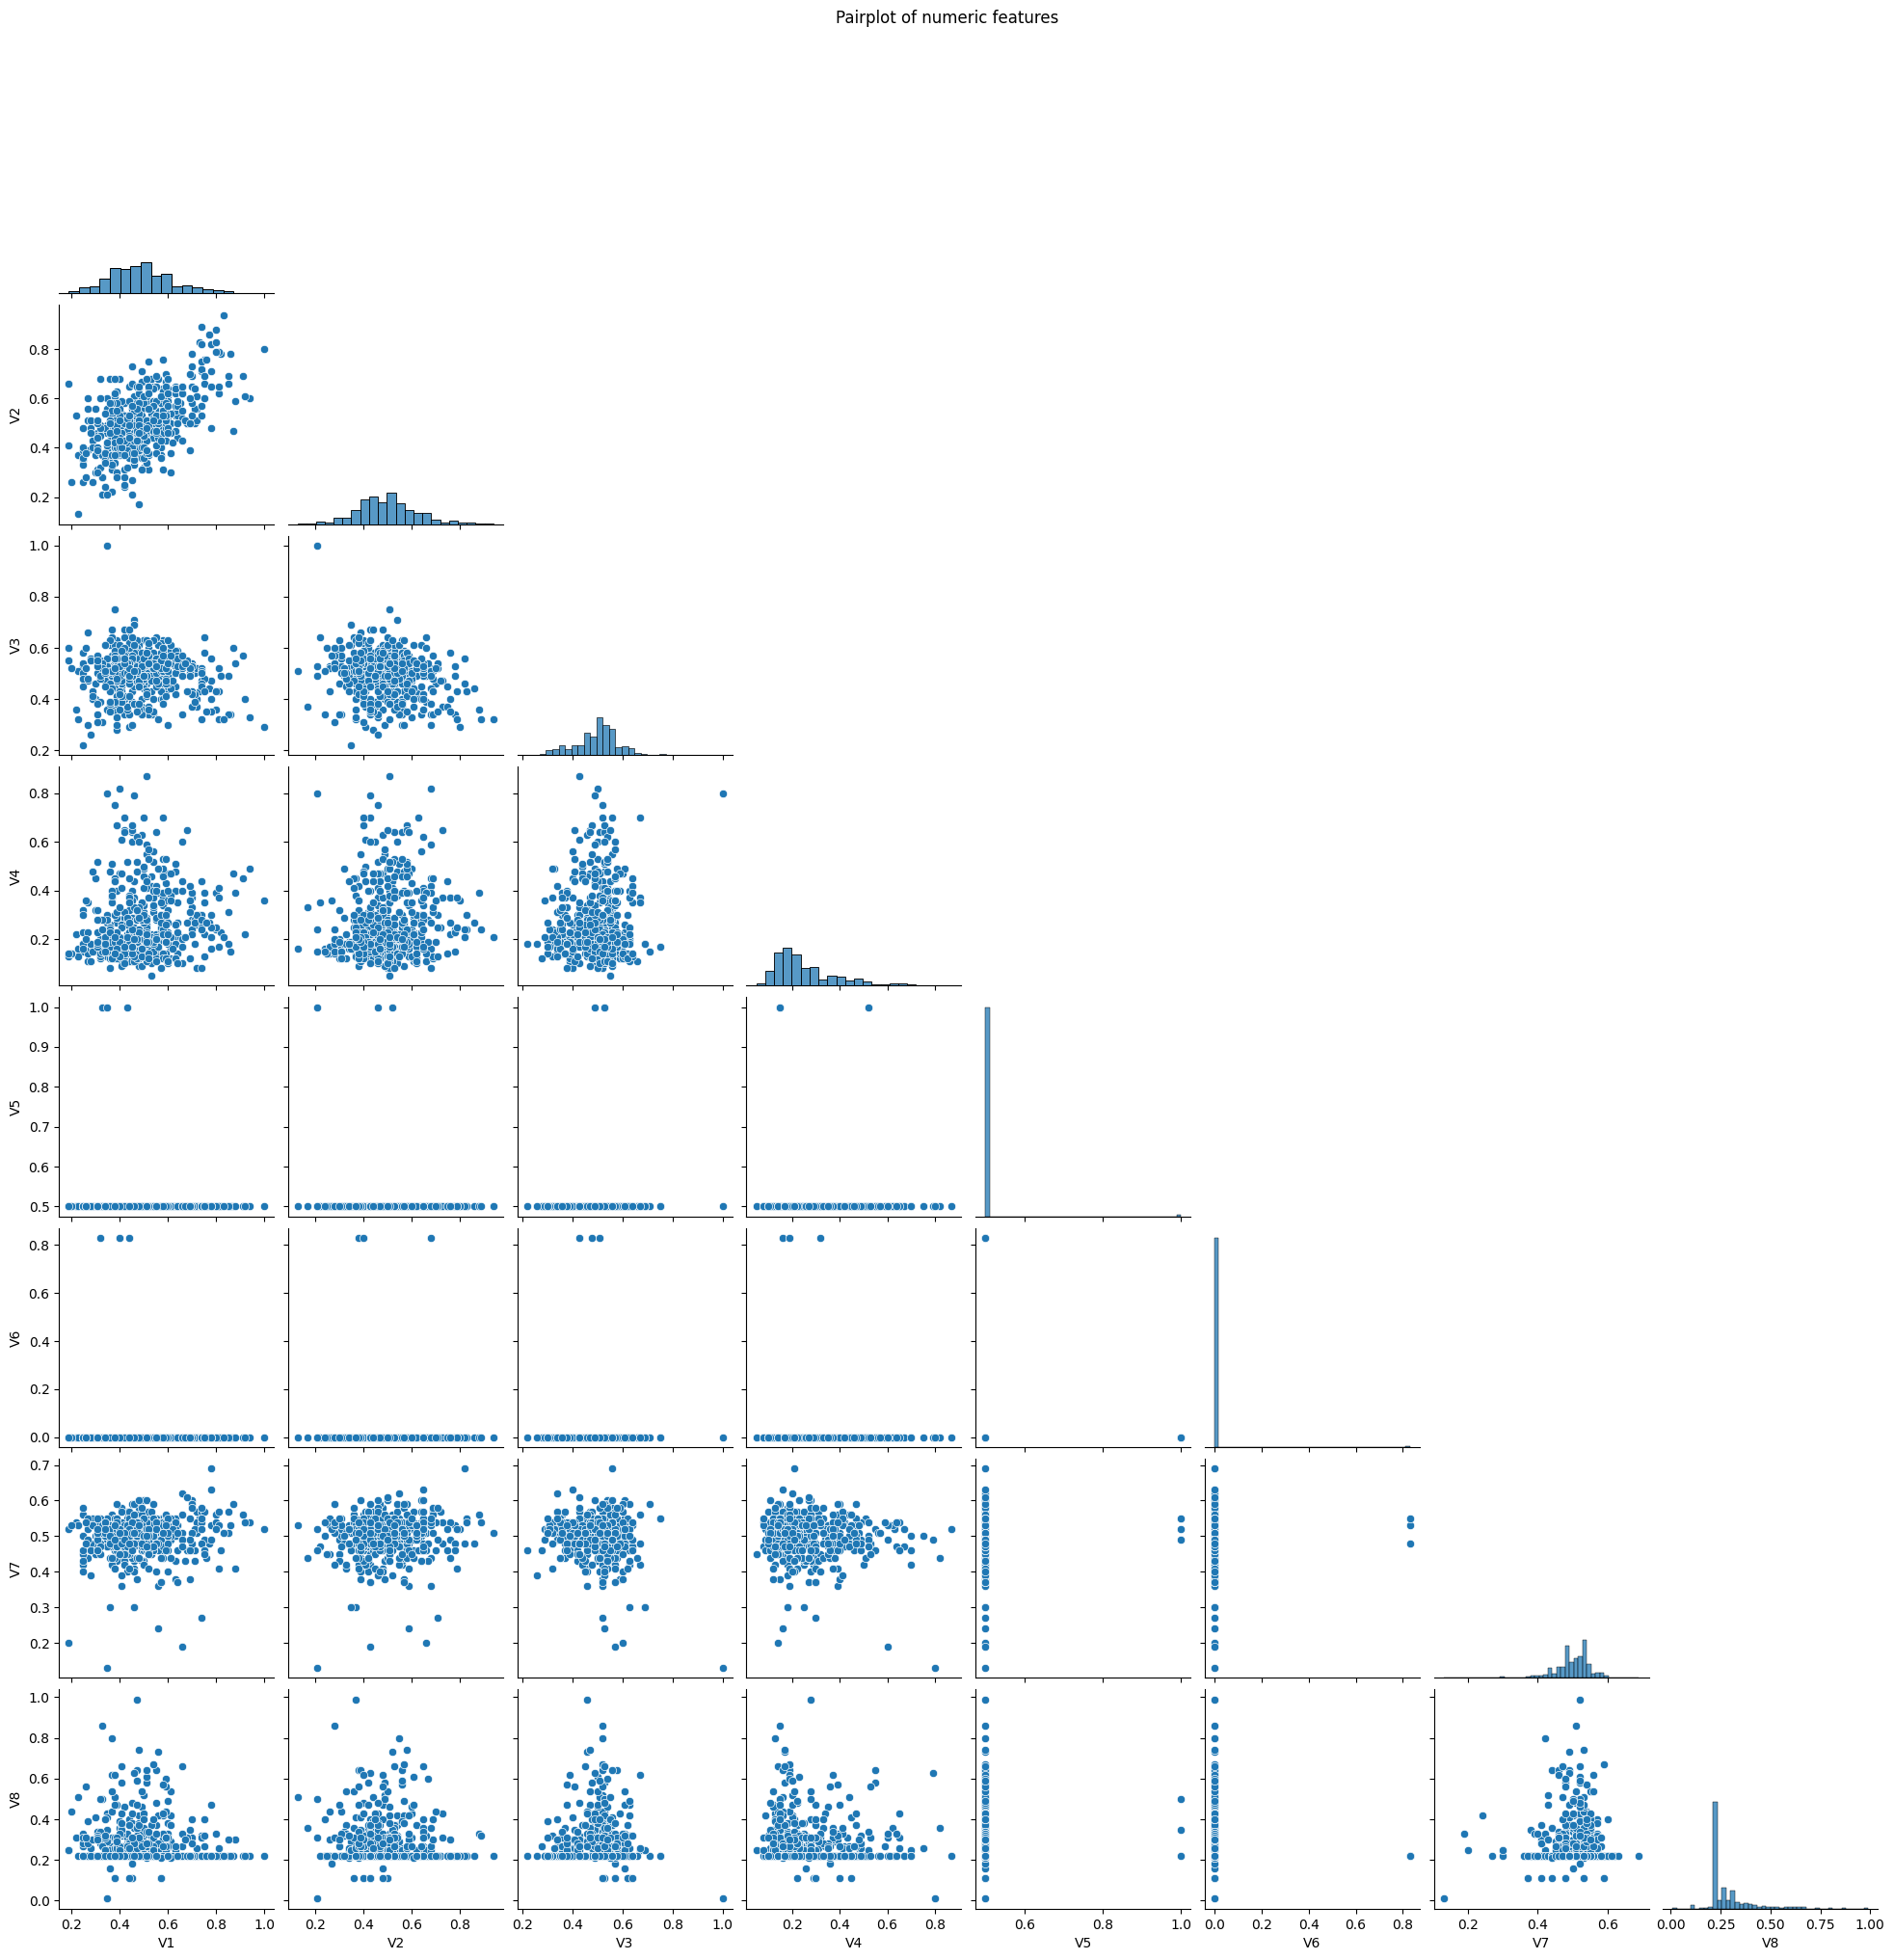

In [10]:

# ---------- Pairplot ----------
# Pairplot can be heavy on large datasets; sample if needed
sample_df = df[numeric_cols].sample(min(len(df), 500), random_state=42)
sns.pairplot(sample_df, corner=True, diag_kind="hist")
plt.suptitle("Pairplot of numeric features", y=1.02)
plt.show()


In [12]:
# ============================================================
# 2) COMMENT / CHECKS: imbalance, outliers, missing, ID-like cols
# ============================================================

# --- Missing values already printed; keep a boolean summary ---
missing_total = int(df.isna().sum().sum())
print("\nTOTAL missing values in dataset:", missing_total)



TOTAL missing values in dataset: 0


In [13]:
# --- Detect non-numeric fields with ~unique per row (ID-like) ---
n_rows = len(df)
for col in non_numeric_cols:
    nunique = df[col].nunique(dropna=False)
    ratio = nunique / n_rows if n_rows else 0
    print(f"Non-numeric col '{col}': distinct={nunique} (ratio={ratio:.2f} of rows)")
    if ratio > 0.90:
        print(f"  -> '{col}' behaves like an identifier (many distinct values).")


Non-numeric col 'V0': distinct=1462 (ratio=0.99 of rows)
  -> 'V0' behaves like an identifier (many distinct values).


In [14]:
# --- Outliers via IQR rule per numeric feature ---
outlier_report = {}
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outlier_report[col] = len(outliers)


In [15]:
print("\nOutlier counts per numeric column (IQR rule):")
for k, v in outlier_report.items():
    print(f"{k}: {v}")


Outlier counts per numeric column (IQR rule):
V1: 31
V2: 38
V3: 71
V4: 70
V5: 14
V6: 15
V7: 98
V8: 134


In [16]:
# --- "Imbalanced distributions" (numeric): quick check of mass at a single value ---
# This detects columns with a dominant value (e.g., many 0.0 or many 0.5)
print("\nDominant value share per numeric column:")
for col in numeric_cols:
    top_share = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    top_value = df[col].value_counts(dropna=False).index[0]
    print(f"{col}: top value={top_value} share={top_share:.2f}")
    if top_share >= 0.80:
        print(f"  -> '{col}' is highly concentrated (strongly imbalanced distribution).")


Dominant value share per numeric column:
V1: top value=0.45 share=0.04
V2: top value=0.46 share=0.04
V3: top value=0.53 share=0.06
V4: top value=0.18 share=0.06
V5: top value=0.5 share=0.99
  -> 'V5' is highly concentrated (strongly imbalanced distribution).
V6: top value=0.0 share=0.99
  -> 'V6' is highly concentrated (strongly imbalanced distribution).
V7: top value=0.51 share=0.11
V8: top value=0.22 share=0.52



- Size/structure: The dataset contains N rows and M columns. V1..V8 are numeric features, while V0 is non-numeric.
- Missing values: Checking df.isna().sum() shows [no / some] missing values. If missing_total = 0, no imputation is required.
- Non-numeric / ID-like fields: V0 has almost one distinct value per record (nunique ≈ number of rows), so it behaves like an identifier. It should not be used directly as a predictive feature (it does not carry generalizable numeric information).
- Distributions/imbalance: Boxplots and histograms show whether features are symmetric or skewed and whether many points concentrate at one value (e.g., 0.0 or 0.5). If “Dominant value share” is high (≥ 0.80), that feature’s distribution is imbalanced/concentrated.
- Outliers: Using the IQR rule, outlier counts per column are reported. Visible points beyond whiskers in the boxplot confirm outliers. Outliers may affect distance-based methods (KNN, K-means) and can motivate robust scaling or winsorization.
- Pairplot: The pairplot highlights correlations/relationships between features and potential clusters. Strong linear trends suggest correlation; overlapping clouds suggest weak separability.


In [17]:
# ============================================================
# 1) DROP COLUMNS NOT RELEVANT FOR CLUSTERING
# ============================================================



# Identify non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)



# Drop non-numeric (ID-like) columns
df_clustering = df.drop(columns=non_numeric_cols)

print("\nShape after dropping non-relevant columns:", df_clustering.shape)
print("Remaining columns:", df_clustering.columns.tolist())


Non-numeric columns: ['V0']

Shape after dropping non-relevant columns: (1484, 8)
Remaining columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8']


In [18]:
# ============================================================
# 2) HANDLE MISSING VALUES
# ============================================================


# Check missing values
print("\nMissing values per column:")
print(df_clustering.isna().sum())

total_missing = df_clustering.isna().sum().sum()
print("\nTotal missing values:", total_missing)

# If missing values exist, apply imputation
if total_missing > 0:
    # Mean imputation (standard choice for numeric features in clustering)
    df_clustering = df_clustering.fillna(df_clustering.mean())
    print("\nMissing values handled using mean imputation.")
else:
    print("\nNo missing values detected. No imputation needed.")

# Final sanity check
print("\nFinal dataset info for clustering:")
print(df_clustering.info())


Missing values per column:
V1    0
V2    0
V3    0
V4    0
V5    0
V6    0
V7    0
V8    0
dtype: int64

Total missing values: 0

No missing values detected. No imputation needed.

Final dataset info for clustering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      1484 non-null   float64
 1   V2      1484 non-null   float64
 2   V3      1484 non-null   float64
 3   V4      1484 non-null   float64
 4   V5      1484 non-null   float64
 5   V6      1484 non-null   float64
 6   V7      1484 non-null   float64
 7   V8      1484 non-null   float64
dtypes: float64(8)
memory usage: 92.9 KB
None


Dropping columns

Column V0 is non-numeric and has almost one distinct value per record, behaving like an identifier.

Clustering algorithms (e.g., K-means, DBSCAN, hierarchical) rely on distance computations and require numeric, comparable features.

Keeping an identifier would introduce artificial distances with no semantic meaning.

Therefore, V0 is dropped, and only numeric features V1–V8 are retained.

In [19]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler


# ---------- (Recommended) scale features for KMeans ----------
scaler = StandardScaler()
X = scaler.fit_transform(df_clustering.values)


In [20]:
# ---------- Hyperparameter grid (show/print later) ----------
k_values = range(3, 11)  # not less than 3 clusters
kmeans_fixed_params = {
    "init": "k-means++",
    "n_init": 50,
    "max_iter": 500,
    "random_state": 42,
    "algorithm": "lloyd",
}

In [21]:
# ---------- Search best k by average silhouette ----------
results = []
for k in k_values:
    model = KMeans(n_clusters=k, **kmeans_fixed_params)
    labels = model.fit_predict(X)
    s = silhouette_score(X, labels)
    results.append((k, s))

results_df = pd.DataFrame(results, columns=["k", "silhouette_avg"]).sort_values(
    "silhouette_avg", ascending=False
)

results_df.head()

,k,silhouette_avg
3,6,0.230373
4,7,0.226807
5,8,0.224000
2,5,0.209942
1,4,0.208330


In [22]:
best_k = int(results_df.iloc[0]["k"])
best_s = float(results_df.iloc[0]["silhouette_avg"])


In [23]:
print("KMeans hyperparameters (fixed):", kmeans_fixed_params)
print("\nSilhouette results (sorted):")
print(results_df.to_string(index=False))
print(f"\nBest k: {best_k} with avg silhouette: {best_s:.4f}")


KMeans hyperparameters (fixed): {'init': 'k-means++', 'n_init': 50, 'max_iter': 500, 'random_state': 42, 'algorithm': 'lloyd'}

Silhouette results (sorted):
 k  silhouette_avg
 6        0.230373
 7        0.226807
 8        0.224000
 5        0.209942
 4        0.208330
 9        0.202060
 3        0.198769
10        0.184840

Best k: 6 with avg silhouette: 0.2304


In [25]:
# ---------- Fit best model ----------
best_model = KMeans(n_clusters=best_k, **kmeans_fixed_params)
best_labels = best_model.fit_predict(X)

print("\nBest model hyperparameters:")
print(best_model.get_params())



Best model hyperparameters:
{'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 500, 'n_clusters': 6, 'n_init': 50, 'random_state': 42, 'tol': 0.0001, 'verbose': 0}


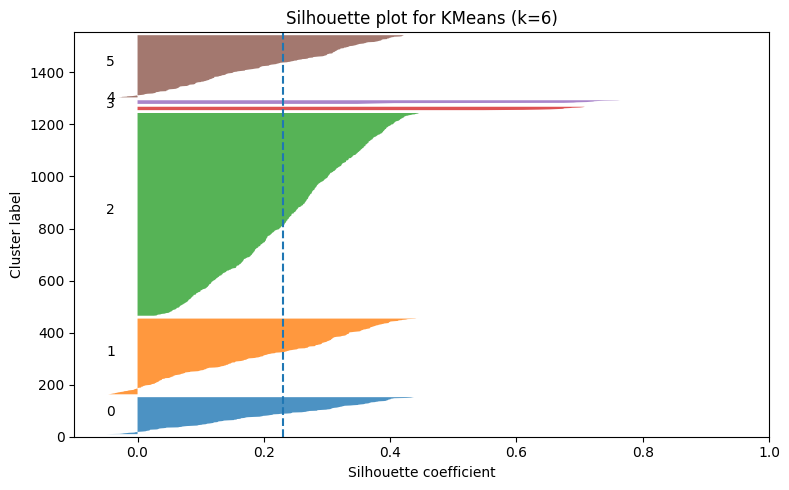

In [26]:
# ---------- Silhouette plot for the best k ----------
sample_silhouette_values = silhouette_samples(X, best_labels)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim([-0.1, 1.0])
ax.set_ylim([0, len(X) + (best_k + 1) * 10])

y_lower = 10
for i in range(best_k):
    ith_vals = sample_silhouette_values[best_labels == i]
    ith_vals.sort()
    size_i = ith_vals.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_vals,
        alpha=0.8,
    )
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=best_s, linestyle="--")
ax.set_title(f"Silhouette plot for KMeans (k={best_k})")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster label")
plt.tight_layout()
plt.show()

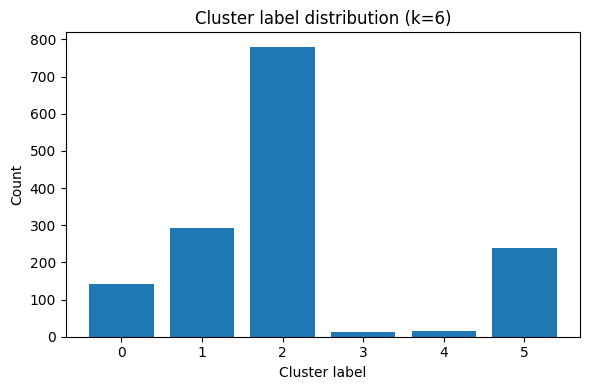

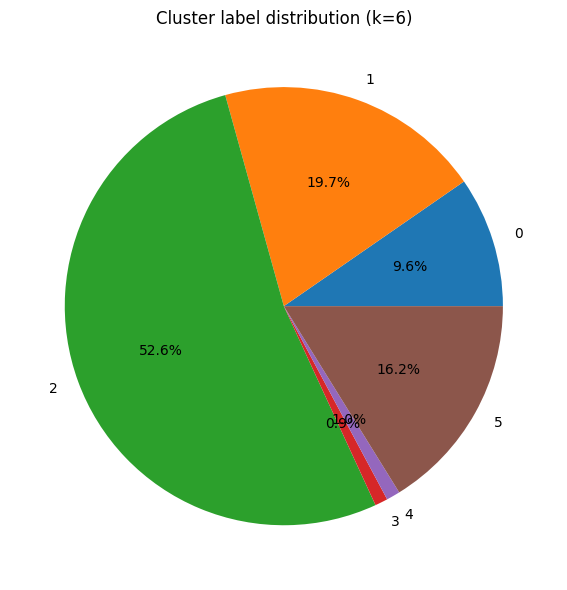

In [27]:
# ---------- Label distribution (histogram + pie) ----------
labels_series = pd.Series(best_labels, name="cluster")
counts = labels_series.value_counts().sort_index()

# Histogram / bar
plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title(f"Cluster label distribution (k={best_k})")
plt.xlabel("Cluster label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=[str(i) for i in counts.index], autopct="%1.1f%%")
plt.title(f"Cluster label distribution (k={best_k})")
plt.tight_layout()
plt.show()

Agglomerative clustering hyperparameters:
{'linkage': 'ward', 'metric': 'euclidean'}

Silhouette results:
 k  silhouette_avg
 3        0.688929
 4        0.252597
 7        0.210002
 8        0.204053
 6        0.197224
 5        0.185147
10        0.151384
 9        0.149737

Best number of clusters: k = 3
Best average silhouette score: 0.6889


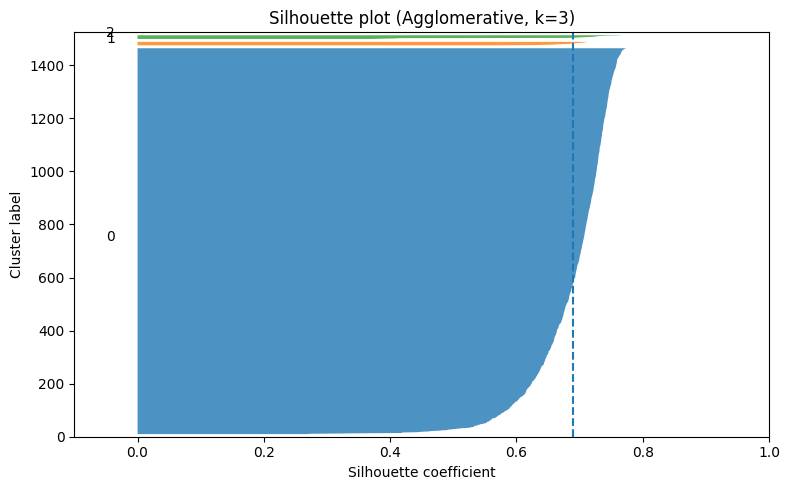

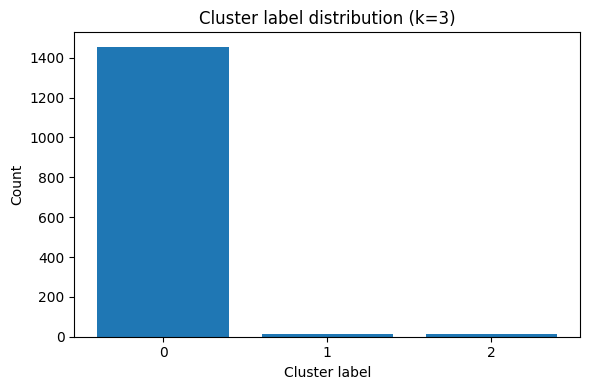

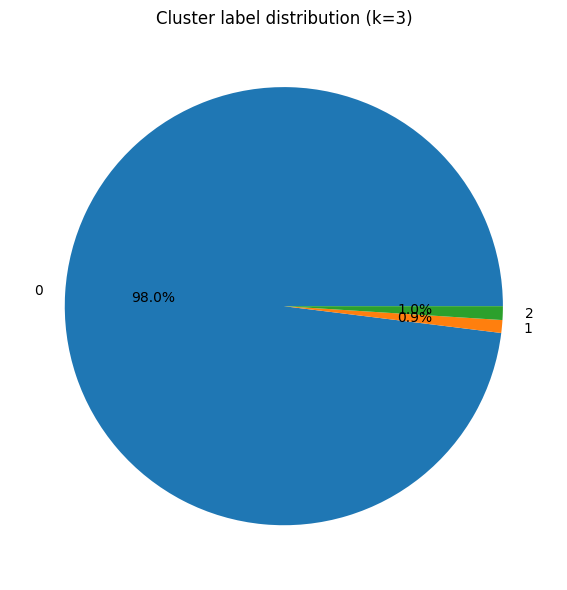

In [28]:
# ============================================================
# AGGLOMERATIVE CLUSTERING
# - k >= 3
# - select best k by silhouette
# - show hyperparameters
# - silhouette plot
# - cluster label distribution
# Assumes: df_clustering (numeric, no NaNs) already exists
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

# ---------- Scale features (important for distance-based clustering) ----------
scaler = StandardScaler()
X = scaler.fit_transform(df_clustering.values)

# ---------- Hyperparameter space ----------
k_values = range(3, 11)   # not less than 3 clusters
linkage = "ward"          # fixed (requires Euclidean distance)
metric = "euclidean"

# ---------- Search best k using silhouette ----------
results = []

for k in k_values:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage=linkage,
        metric=metric
    )
    labels = model.fit_predict(X)
    s = silhouette_score(X, labels)
    results.append((k, s))

results_df = pd.DataFrame(results, columns=["k", "silhouette_avg"]) \
               .sort_values("silhouette_avg", ascending=False)

best_k = int(results_df.iloc[0]["k"])
best_s = float(results_df.iloc[0]["silhouette_avg"])

print("Agglomerative clustering hyperparameters:")
print({
    "linkage": linkage,
    "metric": metric
})

print("\nSilhouette results:")
print(results_df.to_string(index=False))

print(f"\nBest number of clusters: k = {best_k}")
print(f"Best average silhouette score: {best_s:.4f}")

# ---------- Fit best model ----------
best_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage=linkage,
    metric=metric
)
best_labels = best_model.fit_predict(X)

# ---------- Silhouette plot ----------
silhouette_vals = silhouette_samples(X, best_labels)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim([-0.1, 1.0])
ax.set_ylim([0, len(X) + (best_k + 1) * 10])

y_lower = 10
for i in range(best_k):
    ith_vals = silhouette_vals[best_labels == i]
    ith_vals.sort()
    size_i = ith_vals.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_vals,
        alpha=0.8
    )
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=best_s, linestyle="--")
ax.set_title(f"Silhouette plot (Agglomerative, k={best_k})")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster label")
plt.tight_layout()
plt.show()

# ---------- Cluster label distribution ----------
labels_series = pd.Series(best_labels, name="cluster")
counts = labels_series.value_counts().sort_index()

# Histogram / bar plot
plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title(f"Cluster label distribution (k={best_k})")
plt.xlabel("Cluster label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts.values,
    labels=[str(i) for i in counts.index],
    autopct="%1.1f%%"
)
plt.title(f"Cluster label distribution (k={best_k})")
plt.tight_layout()
plt.show()


Top configurations:
 k  linkage    metric  silhouette
 3     ward euclidean    0.688929
 3  average euclidean    0.688929
 4  average euclidean    0.661968
 4  average manhattan    0.661968
 3  average manhattan    0.653732
 4 complete euclidean    0.628234
 4 complete manhattan    0.628234
 3 complete manhattan    0.615883
 3 complete euclidean    0.615354
 5  average euclidean    0.518251

Best configuration:
k                     3
linkage            ward
metric        euclidean
silhouette     0.688929
Name: 0, dtype: object


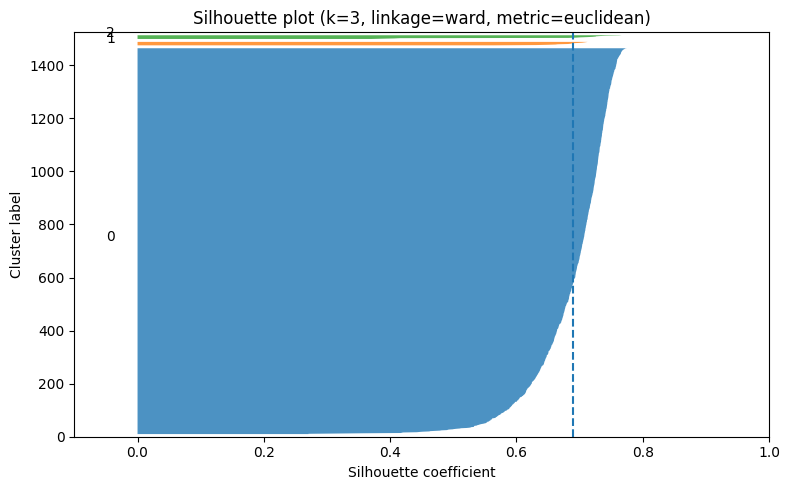

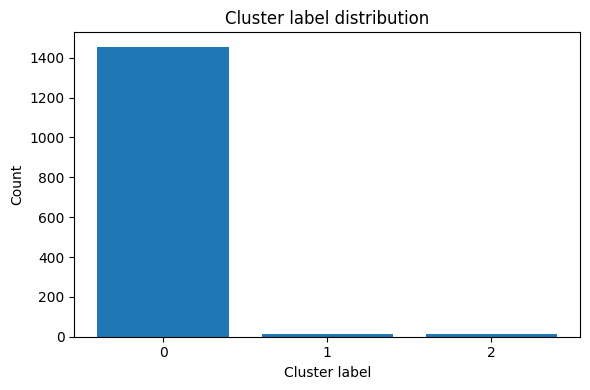

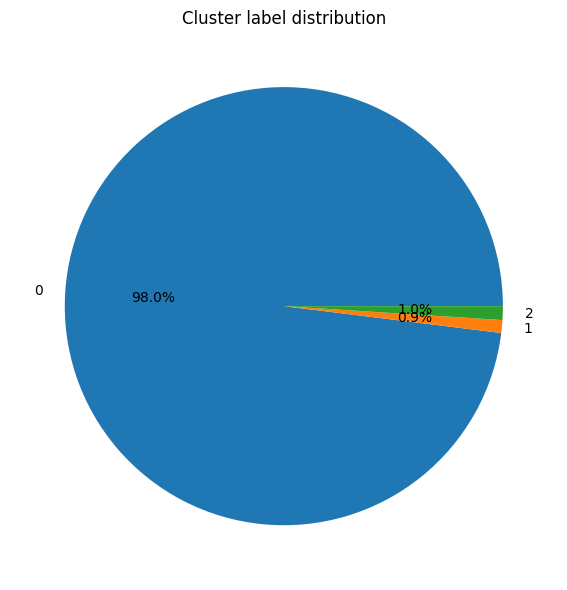

In [29]:
# ============================================================
# AGGLOMERATIVE CLUSTERING — PARAMETER GRID VERSION
# - k >= 3
# - grid over linkage + distance + k
# - select best configuration via silhouette score
# - silhouette plot + cluster distribution
# Assumes: df_clustering already exists (numeric, no NaNs)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

# ---------- Scale data ----------
scaler = StandardScaler()
X = scaler.fit_transform(df_clustering.values)

# ---------- Parameter grid ----------
param_grid = {
    "n_clusters": range(3, 11),
    "linkage": ["ward", "complete", "average"],
    "metric": ["euclidean", "manhattan"]
}

results = []

# ---------- Grid search ----------
for k in param_grid["n_clusters"]:
    for linkage in param_grid["linkage"]:
        for metric in param_grid["metric"]:

            # Ward linkage only works with Euclidean distance
            if linkage == "ward" and metric != "euclidean":
                continue

            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage,
                metric=metric
            )

            labels = model.fit_predict(X)

            # Skip invalid solutions (all points in one cluster)
            if len(np.unique(labels)) < 2:
                continue

            score = silhouette_score(X, labels)

            results.append((k, linkage, metric, score))

# ---------- Results table ----------
results_df = pd.DataFrame(
    results,
    columns=["k", "linkage", "metric", "silhouette"]
).sort_values("silhouette", ascending=False)

print("Top configurations:")
print(results_df.head(10).to_string(index=False))

best_row = results_df.iloc[0]
best_k = int(best_row["k"])
best_linkage = best_row["linkage"]
best_metric = best_row["metric"]
best_score = float(best_row["silhouette"])

print("\nBest configuration:")
print(best_row)

# ---------- Fit best model ----------
best_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage=best_linkage,
    metric=best_metric
)

best_labels = best_model.fit_predict(X)

# ============================================================
# SILHOUETTE PLOT
# ============================================================

silhouette_vals = silhouette_samples(X, best_labels)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim([-0.1, 1.0])
ax.set_ylim([0, len(X) + (best_k + 1) * 10])

y_lower = 10
for i in range(best_k):
    ith_vals = silhouette_vals[best_labels == i]
    ith_vals.sort()
    size_i = ith_vals.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_vals,
        alpha=0.8
    )
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=best_score, linestyle="--")
ax.set_title(
    f"Silhouette plot (k={best_k}, linkage={best_linkage}, metric={best_metric})"
)
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster label")
plt.tight_layout()
plt.show()

# ============================================================
# CLUSTER LABEL DISTRIBUTION
# ============================================================

counts = pd.Series(best_labels).value_counts().sort_index()

# Bar plot
plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Cluster label")
plt.ylabel("Count")
plt.title("Cluster label distribution")
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts.values,
    labels=[str(i) for i in counts.index],
    autopct="%1.1f%%"
)
plt.title("Cluster label distribution")
plt.tight_layout()
plt.show()
